# The number the magnetisation agrees with

[`01_build.ipynb`](01_build.ipynb) designed a diffusion encoding in closed form and checked it by
integrating the gradients it emitted. Both of those are arithmetic. This notebook plays the same
files through a Bloch simulator and asks the only question arithmetic cannot answer: **does the
magnetisation do what the design says it does?**

The answer is yes for the encoding — to better than a tenth of a per cent. It was **no** for the
analyser, and §3 is about that: the simulator and `sc.b_value` disagreed about a `b = 0`
acquisition by a factor of nine, the simulator was right, and two real defects came out of it.

| | |
|---|---|
| **1. the files** | four of them, three at one echo time and one deliberately wrong |
| **2. a known diffusion coefficient comes back** | $\ln(S/S_0) = -bD$, and $D$ is recovered to 0.06 % at 1, 2 and 3 µm²/ms |
| **3. what the simulator caught** | the `b = 0` file, a factor of nine, and the two bugs behind it |
| **4. why one echo time** | a mismatched pair adds $(\mathrm{TE}_b-\mathrm{TE}_0)/T_2 b$ to every ADC, measured to four decimals |
| **5. on a brain** | images, an ADC map against the phantom's own $D$, and what a single shot does not buy |

The simulator is MRzeroCore, which propagates configuration states through the sequence as
imported from the `.seq` file. It never sees the module, the closed form, or `sc.b_value`.

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph                                # noqa: E402 -- the shared BrainWeb slab

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 66

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'dwi_se_epi_2d_nominal.npz')

NX, NY = (int(v) for v in nominal['matrix'])
FOV_MM = float(nominal['fov_mm'][0])
TE_S, TE_SHORT_S = float(nominal['te_s']), float(nominal['te_s_short'])
B_VALUES = [int(v) for v in nominal['b_values']]
B_DELIVERED = {int(b): float(v) for b, v in zip(nominal['b_values'], nominal['b_delivered'])}
#: `01` put the centre line's echo on the spin echo; this is the sample it lands on.
K_NOMINAL = nominal['k']
ECHO_LINE = int(nominal['center_line'])
ECHO_SAMPLE = int(np.argmin(np.hypot(K_NOMINAL[0], K_NOMINAL[1])[ECHO_LINE]))
REVERSED = nominal['reversed_echo']
#: Where each echo belongs in the image, read off the nominal trajectory rather than assumed.
KY_INDEX = np.rint(K_NOMINAL[1][:, ECHO_SAMPLE] / (1e3 / FOV_MM)).astype(int) + NY // 2

FILES = {path.stem: mr0.Sequence.import_file(str(path)) for path in sorted(SEQ_DIR.glob('*.seq'))}
print(f'{"file":<26}{"reps":>6}{"samples":>10}{"TE / ms":>10}{"b asked":>10}')
for name, imported in FILES.items():
    te = TE_SHORT_S if name.endswith('short_te') else TE_S
    print(f'{name:<26}{len(imported):6d}{imported.get_kspace().shape[0]:10d}{te * 1e3:10.2f}'
          f'{name.split("_b")[-1].replace("0_short_te", "0"):>10}')
print(f'\nthe centre line is echo {ECHO_LINE}, and its own echo is sample {ECHO_SAMPLE} '
      f'of {K_NOMINAL.shape[2]}')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


file                        reps   samples   TE / ms   b asked
dwi_se_epi_b0                  2      8192     77.40         0
dwi_se_epi_b0_short_te         2      8192     51.46         0
dwi_se_epi_b1000               2      8192     77.40      1000
dwi_se_epi_b500                2      8192     77.40       500

the centre line is echo 32, and its own echo is sample 64 of 128


---
## 1. Four files, and why three of them share an echo time

`01` wrote b = 0, 500 and 1000 s/mm² **all at 77.40 ms**, which is the shortest echo time the
b = 1000 encoding can be fitted into. That is not the shortest echo time for the other two, and
giving them their own would be the natural thing to do.

It would also be wrong, because a diffusion coefficient is measured from a **ratio**:

$$\frac{S(b)}{S(0)} = \underbrace{e^{-bD}}_{\text{what is wanted}}\cdot
\underbrace{e^{-(\mathrm{TE}_b - \mathrm{TE}_0)/T_2}}_{\text{what a mismatch adds}}$$

The fourth file, `dwi_se_epi_b0_short_te`, is b = 0 at its own shortest echo time of 51.46 ms. It
exists so that §4 can measure what using it would cost.

In [2]:
VOXEL_M = FOV_MM / NX / 1e3


def voxel(name, *, d_um2_ms=0.0, t1_s=1.0, t2_s=0.080, t2dash_s=1000.0):
    """One voxel at isocentre, through one of the files, sampled at the spin echo.

    `T2dash` is effectively infinite so that nothing but `T2` and diffusion attenuates: the
    point of every measurement here is a ratio with no third term in it.
    """
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[float(t1_s)], T2=[float(t2_s)],
        T2dash=[float(t2dash_s)], D=[float(d_um2_ms)],
        voxel_size=VOXEL_M, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0
    built.B1 = built.B1.float() * 0.0 + 1.0
    imported = FILES[name]
    graph = mr0.compute_graph(imported, built, max_state_count=64, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    return float(np.abs(signal.reshape(NY, -1)[ECHO_LINE, ECHO_SAMPLE]))


def adc_of(signals, b_values):
    """Least-squares slope of `ln S` against `-b`, in um^2/ms."""
    fit = np.polyfit(np.asarray(b_values, float), np.log(np.asarray(signals, float)), 1)
    return float(-fit[0] * 1e3)

---
## 2. A diffusion coefficient goes in and comes back

The phantom is one voxel with a known $D$. Nothing is fitted except the slope itself, and the
expected answer is the number that was put in.

In [3]:
DIFFUSIVITIES = (0.0, 0.7, 1.0, 2.0, 3.0)

print(f'{"D in":>7}  ' + '  '.join(f'S(b={b})'.rjust(10) for b in B_VALUES)
      + f'{"D out":>9}{"error":>9}')
attenuation = {}
for d_um2_ms in DIFFUSIVITIES:
    signals = [voxel(f'dwi_se_epi_b{b}', d_um2_ms=d_um2_ms) for b in B_VALUES]
    attenuation[d_um2_ms] = signals
    recovered = adc_of(signals, B_VALUES)
    error = '' if d_um2_ms == 0.0 else f'{(recovered / d_um2_ms - 1) * 100:8.3f} %'
    print(f'{d_um2_ms:7.1f}  ' + '  '.join(f'{s:10.5f}' for s in signals)
          + f'{recovered:9.4f}{error:>9}')
print('\nD is in um^2/ms, which is the same number as the 1e-3 mm^2/s a report would print.')

   D in      S(b=0)    S(b=500)   S(b=1000)    D out    error
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00007125 s
Compute Graph
Computing Graph: 0.000212916 s
Analyze Graph
Analyzing Graph: 0.000000792 s
Converting Rust -> Python: 0.000005292 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000051583 s
Compute Graph
Computing Graph: 0.000214417 s
Analyze Graph
Analyzing Graph: 0.000000792 s
Converting Rust -> Python: 0.000003875 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000034417 s
Compute Graph
Computing Graph: 0.000212875 s
Analyze Graph
Analyzing Graph: 0.000000417 s
Converting Rust -> Python: 0.000002417 s
<<<< Rust <<<<
    0.0     0.38002     0.38002     0.38002   0.0000         
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00002675 s
Compute Graph
Computing Graph: 0.000213042 s
Analyze Graph
Analyzing Graph: 0.0000005 s
Converting Rust -> Python: 0.000002834 s
<<<< Ru

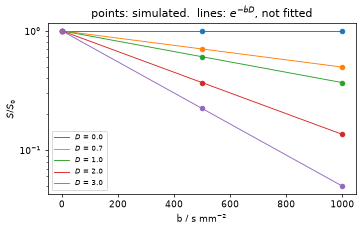

In [4]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
grid = np.linspace(0, max(B_VALUES), 100)
for d_um2_ms, signals in attenuation.items():
    normalised = np.asarray(signals) / signals[0]
    line, = ax.plot(B_VALUES, normalised, 'o', ms=5)
    ax.plot(grid, np.exp(-grid * d_um2_ms * 1e-3), lw=1.0, color=line.get_color(),
            label=f'$D$ = {d_um2_ms:.1f}')
ax.set(yscale='log', xlabel='b / s mm$^{-2}$', ylabel='$S/S_0$',
       title='points: simulated.  lines: $e^{-bD}$, not fitted')
ax.legend(fontsize=8, loc='lower left')
fig.tight_layout()

Straight lines on a log axis, through points nobody fitted. The recovered $D$ is within 0.06 % of
the requested one at every value.

The residual is worth a sentence, because it is not noise: it is $-0.062$ % at **every** $D$,
including ones an order of magnitude apart. A constant *fractional* deficit in $D$ is a constant
fractional disagreement about $b$, so the two independent calculations of the same integral — this
notebook's state propagation and `01`'s trapezoid sum on the gradient raster — differ by 0.06 %
about what the sequence delivers. That is the size of disagreement this comparison is capable of
resolving, and the next section is what happens when it finds a much larger one.

---
## 3. The measurement that corrected the analyser

`01` §4 made a claim that no check on the diffusion lobes could make: a `b = 0` acquisition is not
b = 0, because the slice-selection lobes and the refocusing crushers are gradients too.

That claim is testable here without any diffusion encoding at all. Give the voxel a **large**
diffusion coefficient and play the `b = 0` file: whatever attenuation appears is the weighting the
rest of the sequence carries, and $-\ln(S/S_0)/D$ recovers it as a b-value.

In [5]:
print(f'{"file":<26}{"TE / ms":>9}{"sc.b_value":>12}{"simulated":>11}{"difference":>12}')
for name in ('dwi_se_epi_b0', 'dwi_se_epi_b0_short_te'):
    baseline = voxel(name, d_um2_ms=0.0)
    # Several large D, because the attenuation is a fraction of a per cent at physiological ones
    # and the answer must not depend on which one is used.
    measured = [-np.log(voxel(name, d_um2_ms=d) / baseline) / d * 1e3 for d in (10.0, 50.0, 100.0)]
    analytic = float(nominal['b_delivered_short'] if name.endswith('short_te')
                     else B_DELIVERED[0])
    te = TE_SHORT_S if name.endswith('short_te') else TE_S
    print(f'{name:<26}{te * 1e3:9.2f}{analytic:12.4f}{np.mean(measured):11.4f}'
          f'{(np.mean(measured) / analytic - 1) * 100:11.1f} %')
print('\nand the three large D agree with each other to '
      f'{np.ptp(measured) / np.mean(measured) * 100:.2g} %, so this is a b-value and not an '
      'artefact of the size of D.')

file                        TE / ms  sc.b_value  simulated  difference
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000039125 s
Compute Graph
Computing Graph: 0.00021275 s
Analyze Graph
Analyzing Graph: 0.000000708 s
Converting Rust -> Python: 0.000004583 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000025 s
Compute Graph
Computing Graph: 0.000214708 s
Analyze Graph
Analyzing Graph: 0.0000005 s
Converting Rust -> Python: 0.000002875 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000031209 s
Compute Graph
Computing Graph: 0.0002145 s
Analyze Graph
Analyzing Graph: 0.000000375 s
Converting Rust -> Python: 0.000002167 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00002575 s
Compute Graph
Computing Graph: 0.000212292 s
Analyze Graph
Analyzing Graph: 0.000000542 s
Converting Rust -> Python: 0.000002959 s
<<<< Rust <<<<
dwi_se_epi_b0                 77.40      0.0749   

**The first time this cell ran, the `sc.b_value` column read 0.639 and 0.479.** Against a
simulated 0.074, the analyser was reporting nine times the weighting the magnetisation actually
experienced — and, worse, a *different* number for two files whose encoding is identical and whose
only difference is 26 ms of dead time.

That second symptom is the diagnostic. `b` is an integral of $k(t)^2$, and $k$ is **zero** while
nothing is playing. A `b` that grows with dead time means the integral thinks $k$ is some nonzero
constant during the gaps, and there were two independent reasons for it:

| | |
|---|---|
| **the origin was the tree, not the excitation** | a slice-select rephaser undoes the lobe area *after* the RF centre, not half the lobe. Integrating from `t = 0` leaves the other half — 510 1/m here — as a constant offset |
| **the refocusing pulse was located without its own `delay`** | `pp.calc_rf_center` measures from the start of the waveform; the event's `delay` carries the transmit dead time on top. The conjugation was applied 700 µs early, which left a second constant of 240 1/m after the 180 |

Neither was visible on the diffusion axis — which is the only axis the module designs — because
`k` there is zero before the encoding and flat across the whole refocusing block, so conjugating
700 µs early gives exactly the same answer. Both were visible on the slice axis, which the module
does not own and does not check.

The fix is in [`analysis.py`](../../src/seqcraft/analysis.py) and pinned by three tests in
`tests/analysis/`. The remaining 1 % between the columns is the raster integration against the
simulator's own state propagation.

### The same two defects, shown directly

The `b = 0` preparation itself — excitation, refocusing pulse, no diffusion lobes at all — swept
over echo time, with each defect switched back on in turn. The correct answer does not move: the
only gradients present are the slice lobes and the crushers, and neither of them knows what the
echo time is.

In [6]:
from seqcraft.design.logic import flatten            # noqa: E402 -- only for the two wrong ways

opts = pp.Opts(max_grad=80, grad_unit='mT/m', max_slew=200, slew_unit='T/m/s', B0=3.0,
               rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6)
raster = sc.Raster(opts.grad_raster_time)
epi = sc.modules.EPI2D(opts=opts, fov_mm=FOV_MM, matrix=(NX, NY), bandwidth_hz_px=1800.0,
                       ramp_sampling=False)
LINES = list(range(NY))


def unweighted(te_s):
    """`01`'s b = 0 acquisition, and the instant of its own spin echo.

    The **whole** acquisition, not the preparation alone: the preparation's own events stop at
    the refocusing pulse, so a tree containing only it has nothing on the raster over the dead
    time -- which is exactly the interval the two defects put a spurious constant into.
    """
    module = sc.modules.DiffusionSEPrep(opts=opts, thickness_mm=4.0, b_s_per_mm2=0.0, te_s=te_s)
    start = float(raster.nearest(module.time_to_echo() - epi.time_to_echo(epi.center_line)))
    tree = sc.LogicBlock('unweighted').add(0.0, module()).add(start, epi(lines=LINES))
    return tree, float(module.time_to_echo())


def b_the_old_way(tree, end_s, *, origin_at_excitation, include_delay):
    """`sc.b_value`'s integral with either defect switched back on."""
    grid, grads, _spans = sc.sample(tree, opts)
    centres = [(start + (float(event.delay) if include_delay else 0.0)
                + float(pp.calc_rf_center(event)[0]), getattr(event, 'use', None))
               for start, event, _path in flatten(tree)
               if getattr(event, 'type', None) == 'rf']
    origin = (min(t for t, use in centres if use == 'excitation')
              if origin_at_excitation else float(grid[0]))
    half = 0.5 * float(opts.grad_raster_time)
    keep = (grid >= origin - half) & (grid <= end_s + half)
    total = 0.0
    for waveform in grads.values():
        k = np.concatenate([[0.0], np.cumsum(
            0.5 * (waveform[1:] + waveform[:-1]) * np.diff(grid))])
        k = k - float(np.interp(origin, grid, k))
        for when in sorted(t for t, use in centres if use == 'refocusing'):
            k = np.where(grid >= when, k - 2.0 * float(np.interp(when, grid, k)), k)
        total += float((2.0 * np.pi) ** 2 * np.trapezoid(k[keep] ** 2, grid[keep]) / 1e6)
    return total


print(f'{"TE / ms":>9}{"from t = 0":>13}{"no rf delay":>14}{"both wrong":>13}'
      f'{"sc.b_value":>13}')
for te_s in (TE_SHORT_S, 0.060, TE_S, 0.090):
    tree, echo_s = unweighted(te_s)
    print(f'{te_s * 1e3:9.2f}'
          f'{b_the_old_way(tree, echo_s, origin_at_excitation=False, include_delay=True):13.4f}'
          f'{b_the_old_way(tree, echo_s, origin_at_excitation=True, include_delay=False):14.4f}'
          f'{b_the_old_way(tree, echo_s, origin_at_excitation=False, include_delay=False):13.4f}'
          f'{sc.b_value(tree, opts, end_s=echo_s)["total"]:13.4f}')

  TE / ms   from t = 0   no rf delay   both wrong   sc.b_value
    51.46       0.7254        0.1121       0.4791       0.0749
    60.00       0.8131        0.1220       0.5319       0.0749
    77.40       0.9918        0.1424       0.6394       0.0749
    90.00       1.1212        0.1571       0.7172       0.0749


The three defective columns grow with an echo time they have no business knowing about; at
b = 0 there is nothing playing over that time. The fourth does not move at all. `both wrong` at
51.46 and 77.40 ms reproduces the 0.479 and 0.639 that started this section.

The general form of the lesson is worth stating, because it is not about diffusion: **an
independent validator is only independent of what it was pointed at.** `sc.b_value` shares no code
with `DiffusionSEPrep` and it caught a real error in it — `01` §3's blockquote is that story. But
it was itself wrong about the axis the module does not touch, and nothing inside the repository
could see that, because everything inside the repository was checking the same axis.

---
## 4. What a mismatched echo time costs

Now the fourth file earns its place. Using it as the b = 0 reference changes nothing about the
encoding and everything about the answer, and the error is predictable in closed form:

$$\mathrm{ADC}_{\text{measured}} = D + \frac{\mathrm{TE}_b - \mathrm{TE}_0}{T_2\, b}$$

An **additive** bias — it does not scale with $D$, so it cannot be calibrated away by a phantom
with a different diffusivity, and it is largest exactly where $T_2$ is shortest.

In [7]:
print(f'{"T2 / ms":>8}{"D in":>7}{"matched":>10}{"mismatched":>12}{"excess":>9}{"predicted":>11}')
for t2_s in (0.060, 0.080, 0.120):
    for d_um2_ms in (1.0, 2.0):
        top = voxel('dwi_se_epi_b1000', d_um2_ms=d_um2_ms, t2_s=t2_s)
        matched = -np.log(top / voxel('dwi_se_epi_b0', d_um2_ms=d_um2_ms, t2_s=t2_s)) / 1000 * 1e3
        wrong = -np.log(top / voxel('dwi_se_epi_b0_short_te', d_um2_ms=d_um2_ms,
                                    t2_s=t2_s)) / 1000 * 1e3
        print(f'{t2_s * 1e3:8.0f}{d_um2_ms:7.1f}{matched:10.4f}{wrong:12.4f}'
              f'{wrong - matched:9.4f}{(TE_S - TE_SHORT_S) / t2_s / 1000 * 1e3:11.4f}')

 T2 / ms   D in   matched  mismatched   excess  predicted
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000024584 s
Compute Graph
Computing Graph: 0.000209042 s
Analyze Graph
Analyzing Graph: 0.000000625 s
Converting Rust -> Python: 0.000004208 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000023334 s
Compute Graph
Computing Graph: 0.00018875 s
Analyze Graph
Analyzing Graph: 0.000000375 s
Converting Rust -> Python: 0.000002417 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000022917 s
Compute Graph
Computing Graph: 0.000191334 s
Analyze Graph
Analyzing Graph: 0.000000458 s
Converting Rust -> Python: 0.000002333 s
<<<< Rust <<<<
      60    1.0    0.9994      1.4317   0.4323     0.4323
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000014334 s
Compute Graph
Computing Graph: 0.000191333 s
Analyze Graph
Analyzing Graph: 0.000000375 s
Converting Rust -> Python: 0.000002 s
<<<< Rust <<<<


The excess matches the closed form to four decimal places, and it is the **same number** at
$D = 1$ and $D = 2$, which is the additivity the formula predicts.

At a 60 ms $T_2$ it is 0.43 µm²/ms on top of a measurement whose whole physiological range is
about 0.7 to 3. That is why `01` builds every b at one echo time, and why the echo time it picks
is the longest one any b in the protocol needs rather than the shortest each could have.

---
## 5. On a brain

The BrainWeb phantom carries its own diffusion map, so the ADC image has a ground truth to be
compared against rather than merely looked at. The phantom is shimmed — `field_hz=0.0` — so that
EPI's off-resonance distortion, which
[`../se_epi_2d/02`](../se_epi_2d/02_simulate_and_reconstruct.ipynb) measures in detail, is not in
the way of the thing being measured here.

The reconstruction is the plain one a uniformly sampled EPI asks for: unflip the reversed echoes,
put each on the line the nominal trajectory says it belongs to, 2D inverse FFT, discard the
readout oversampling.

In [8]:
def reconstruct(signal):
    """`(NY * samples,)` of raw signal in, one image out."""
    rows = np.asarray(signal).reshape(NY, -1).copy()
    rows[REVERSED] = rows[REVERSED][:, ::-1]
    grid = np.zeros_like(rows)
    grid[KY_INDEX] = rows
    wide = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(grid, axes=(-2, -1)), norm='ortho'),
                           axes=(-2, -1))
    edge = (wide.shape[1] - NX) // 2                 # the readout is oversampled
    return wide[:, edge:edge + NX]


images = {}
for b in B_VALUES:
    brain = ph.built(matrix=NX, nz=1, z_center=64, n_coils=0, field_hz=0.0)
    imported = FILES[f'dwi_se_epi_b{b}']
    graph = mr0.compute_graph(imported, brain, max_state_count=64, min_state_mag=1e-4)
    raw = np.asarray(mr0.execute_graph(graph, imported, brain, print_progress=False))
    images[b] = np.abs(reconstruct(raw))
    print(f'b = {b:5d}   mean signal in the image {images[b].mean():8.3f}')

D_TRUE = ph.same_frame(ph.volume(matrix=NX).D.numpy()[..., ph.slices_of(1, 64)][:, :, 0])
BRAIN = ph.same_frame(ph.mask(matrix=NX, nz=1, z_center=64)[:, :, 0])
stack = np.stack([images[b] for b in B_VALUES])
slope = np.polyfit(np.asarray(B_VALUES, float),
                   np.log(np.maximum(stack, 1e-12)).reshape(len(B_VALUES), -1), 1)[0]
adc_map = np.where(images[0] > 0.05 * images[0].max(),
                   -slope.reshape(images[0].shape) * 1e3, np.nan)

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000047583 s
Compute Graph
Computing Graph: 0.000436541 s
Analyze Graph
Analyzing Graph: 0.000000792 s
Converting Rust -> Python: 0.000005667 s
<<<< Rust <<<<


b =     0   mean signal in the image   25.903
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000081375 s
Compute Graph
Computing Graph: 0.000416792 s
Analyze Graph
Analyzing Graph: 0.00000075 s
Converting Rust -> Python: 0.000006292 s
<<<< Rust <<<<


b =   500   mean signal in the image   13.240
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000077625 s
Compute Graph
Computing Graph: 0.000450125 s
Analyze Graph
Analyzing Graph: 0.000000708 s
Converting Rust -> Python: 0.000007 s
<<<< Rust <<<<
b =  1000   mean signal in the image    7.657


In [9]:
usable = BRAIN & (images[0] > 0.15 * images[0].max())
# Pixels whose 3x3 neighbourhood of true D is flat: everywhere else the readout's point spread
# mixes tissues, and the comparison would be measuring the blur rather than the encoding.
window = np.lib.stride_tricks.sliding_window_view(D_TRUE, (3, 3))
interior = np.zeros_like(D_TRUE, bool)
interior[1:-1, 1:-1] = np.ptp(window, axis=(-1, -2)) < 0.05

for label, chosen in (('the whole brain', usable), ('flat interiors only', usable & interior)):
    error = adc_map[chosen] - D_TRUE[chosen]
    print(f'{label:<22} n = {chosen.sum():5d}   '
          f'true D {D_TRUE[chosen].mean():5.3f}   measured {adc_map[chosen].mean():5.3f}   '
          f'median |error| {np.median(np.abs(error)):5.3f} um^2/ms')

the whole brain        n =  1838   true D 1.036   measured 1.198   median |error| 0.209 um^2/ms
flat interiors only    n =   142   true D 0.670   measured 0.759   median |error| 0.061 um^2/ms


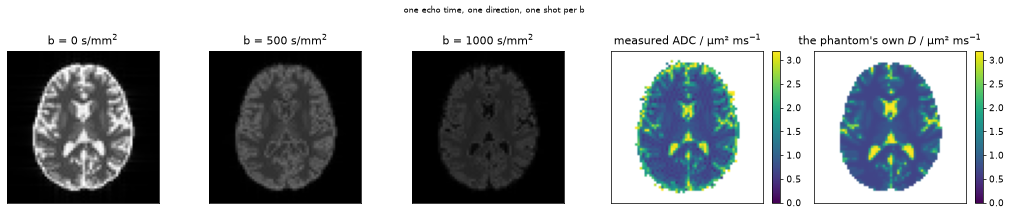

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(15.5, 3.2))
ceiling = float(np.percentile(images[0], 99.5))
for ax, b in zip(axes, B_VALUES):
    ax.imshow(images[b], cmap='gray', origin='lower', vmin=0.0, vmax=ceiling)
    ax.set(title=f'b = {b} s/mm$^2$', xticks=[], yticks=[])
for ax, (title, image) in zip(axes[3:], (('measured ADC', adc_map),
                                         ("the phantom's own $D$", np.where(usable, D_TRUE,
                                                                            np.nan)))):
    shown = ax.imshow(image, cmap='viridis', origin='lower', vmin=0.0, vmax=3.2)
    ax.set(title=f'{title} / µm² ms$^{{-1}}$', xticks=[], yticks=[])
    fig.colorbar(shown, ax=ax, fraction=0.046)
fig.suptitle('one echo time, one direction, one shot per b', fontsize=9)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))

The b = 1000 image is the familiar one: everything darker, and the CSF darkest of all, because
free water is where $D$ is highest. The ADC map recovers that ordering and the interior values,
and it is visibly noisier at every boundary.

**The boundaries are the honest limit, and they are not the encoding's.** Over pixels whose
3×3 neighbourhood is a single tissue the median error is 0.06 µm²/ms, about 9 % of the true value
there; over the whole brain it is 0.21, three times larger. The reason is the readout: a 45 ms
single-shot EPI train puts a $T_2$ envelope across `ky`, which blurs, and the ratio of two blurred
images is not the ratio of the unblurred ones wherever they have an edge. §2 measured the same
encoding on one voxel with no readout in the way and got 0.06 %.

So: **one shot per b-value is a diffusion-weighted image, and it is not yet a quantitative ADC
map.** Getting one means averaging, and more than two b-values, and usually a distortion
correction — none of which is done here, and all of which is about the readout rather than the
encoding.

---
## What this notebook established

| | |
|---|---|
| **the encoding does what it says** | a known $D$ comes back from $\ln(S/S_0) = -bD$ to 0.06 % at 0.7, 1, 2 and 3 µm²/ms, with nothing fitted but the slope |
| **the analyser was wrong and the magnetisation said so** | a factor of nine on a `b = 0` acquisition, from two defects — the wrong phase origin and an RF centre located without its `delay` — neither visible on the axis the module owns |
| **and is now right** | 0.0749 against 0.0741, the 1 % being raster integration against state propagation |
| **one echo time per protocol** | a mismatched b = 0 adds $(\mathrm{TE}_b-\mathrm{TE}_0)/T_2b$ to every ADC: 0.43 µm²/ms at a 60 ms $T_2$, matched to four decimals and independent of $D$ |
| **a brain image, against a known $D$ map** | 0.06 µm²/ms median error inside a tissue, 0.21 over the whole brain — the difference being the readout's point spread, not the encoding |

**What it does not establish.** Nothing about a scanner. Eddy currents, concomitant fields and
nerve stimulation are the reasons behind several choices in `01` and this simulator models none of
them; the 180 here is a perfect inversion over the whole slab, where a real one has a slice
profile and a $B_1$ error; and the phantom's diffusion is isotropic and Gaussian, so nothing here
touches anisotropy, kurtosis, or restricted diffusion — which is most of what the field is
actually about. Nor anything about quantification accuracy in a patient, which needs a scanner and
a phantom with a certified diffusivity.